# IEEE RTS-79 benchmark (24-bus, full-year)

PREP-SHOT validation against the IEEE Reliability Test System (single-area). RTS-79 is the canonical academic benchmark for production-cost models on a real-sized network: 24 buses, 32 generators across 9 plant types (oil, coal, nuclear, hydro), 38 transmission branches, and a documented hourly load profile spanning the full year (8 736 hours).

**Validation thesis.** At the annual peak (2 850 MW) the system's merit-order economic dispatch is unique and the total cost can be computed by hand. Across the year the dispatch follows the textbook "baseload + cycling + peaker" pattern, with each carrier's capacity factor falling in a well-known envelope. Both checks are derived from PREP-SHOT's `c1` linear-cost coefficients alone (no MATLAB / external solver needed for the reference values).

**What this notebook does:**

1. Documents the data sources -- topology, generators, costs, load profile.
2. Plots the network and merit-order curve.
3. Runs PCM full-year (~22 s).
4. Validates annual energy by carrier, capacity factors, and peak-hour dispatch against the merit-order benchmark.

Test in [`tests/test_rts79_benchmark.py`](../../tests/test_rts79_benchmark.py) wraps these checks as a regression.

## 1. Data sources and references

**Primary citation.**  
IEEE Reliability Test System Task Force, Subcommittee on the Application of Probability Methods (1979). "IEEE Reliability Test System." *IEEE Trans. Power App. Syst.*, Vol. PAS-98, No. 6, pp. 2047-2054. https://doi.org/10.1109/TPAS.1979.319398

**MATPOWER reproduction.** [`MATPOWER/data/case24_ieee_rts.m`](https://github.com/MATPOWER/matpower/blob/master/data/case24_ieee_rts.m) -- bus data, branch impedances, generator capacities all from the 1979 paper; cost coefficients from Georgia Tech PSCAL ([http://pscal.ece.gatech.edu/testsys/](http://pscal.ece.gatech.edu/testsys/)).

**Load profile.** Tables 1-3 of the 1979 paper:

* **Table 1** -- weekly peak as % of annual peak (52 weeks, peak in week 51).
* **Table 2** -- daily peak as % of weekly peak (Mon = 93 % to Sun = 75 %).
* **Table 3** -- hourly peak as % of daily peak, by season (winter / summer / spring-fall) x weekday/weekend.

These give the canonical 8 736-hour load shape (52 weeks x 7 days x 24 hours) with annual peak 2 850 MW (= sum of bus Pd at peak).

**Cost simplification.** MATPOWER's cost data is quadratic (`cost = c2 P^2 + c1 P + c0`); PREP-SHOT's `cost_var` is linear. We take the `c1` coefficient as the per-MWh dispatch cost and drop the quadratic and no-load terms. The merit-order benchmark uses the same simplification, so the two should agree exactly at peak.

## 2. Topology and merit order

In [1]:
import pathlib, os, sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

this_dir = pathlib.Path.cwd()
while this_dir.name != 'rts79':
    if this_dir == this_dir.parent:
        raise RuntimeError('run from inside examples/rts79/')
    this_dir = this_dir.parent
INP = this_dir / 'input'

fleet = pd.read_csv(INP / 'tech_existing.csv')
registry = pd.read_csv(INP / 'tech_registry.csv')
varom = pd.read_csv(INP / 'tech_variable_OM_cost.csv')
lines = pd.read_csv(INP / 'transmission_existing.csv')

fleet = fleet.merge(registry[['tech', 'carrier']], on='tech')
fleet = fleet.merge(varom[['tech', 'value']].rename(columns={'value': 'usd_per_mwh'}), on='tech')

print(f'Generators: {len(fleet)} units, total Pmax {fleet.capacity.sum():.0f} MW')
by_carrier = fleet.groupby('carrier').agg(
    nameplate_mw=('capacity', 'sum'),
    n_units=('tech', 'count'),
    cheapest=('usd_per_mwh', 'min'),
    most_expensive=('usd_per_mwh', 'max'),
).sort_values('cheapest')
print('\nCarrier inventory:')
print(by_carrier.to_string())
print(f'\nTransmission: {len(lines) // 2} undirected lines (table has both directions)')

Generators: 32 units, total Pmax 3405 MW

Carrier inventory:
         nameplate_mw  n_units  cheapest  most_expensive
carrier                                                 
hydro           300.0        6    0.0010          0.0010
nuclear         800.0        2    4.4231          4.4231
coal           1274.0        9   11.8495         16.0811
oil            1031.0       15   43.6615        130.0000

Transmission: 34 undirected lines (table has both directions)


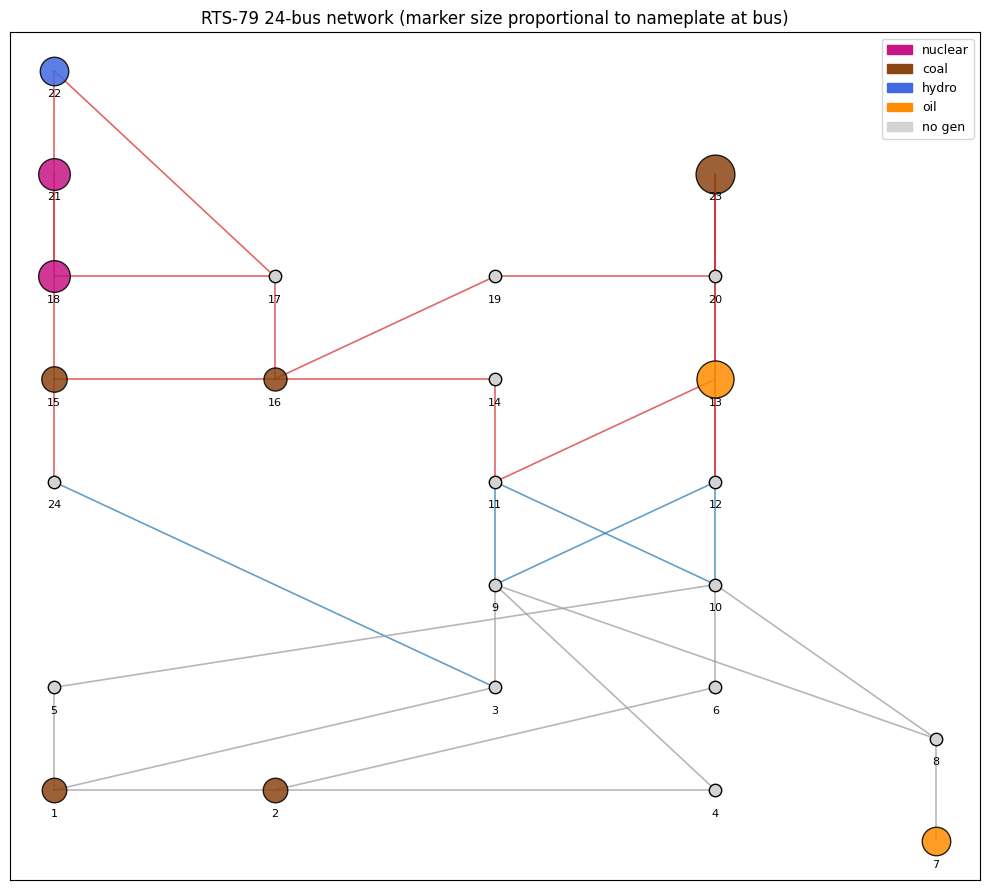

In [2]:
# RTS-79 has a canonical layout from the 1979 paper -- 138 kV and
# 230 kV halves separated geographically.  Approximate positions:
BUS_XY = {
    'bus1': (1, 1), 'bus2': (2, 1), 'bus3': (3, 2), 'bus4': (4, 1),
    'bus5': (1, 2), 'bus6': (4, 2), 'bus7': (5, 0.5), 'bus8': (5, 1.5),
    'bus9': (3, 3), 'bus10': (4, 3),
    'bus11': (3, 4), 'bus12': (4, 4),
    'bus13': (4, 5), 'bus14': (3, 5),
    'bus15': (1, 5), 'bus16': (2, 5), 'bus17': (2, 6), 'bus18': (1, 6),
    'bus19': (3, 6), 'bus20': (4, 6),
    'bus21': (1, 7), 'bus22': (1, 8),
    'bus23': (4, 7), 'bus24': (1, 4),
}
fig, ax = plt.subplots(figsize=(10, 9))
seen = set()
for _, ln in lines.iterrows():
    a, b = sorted([ln['zone1'], ln['zone2']])
    if (a, b) in seen:
        continue
    seen.add((a, b))
    x1, y1 = BUS_XY[a]; x2, y2 = BUS_XY[b]
    color = '#999' if ln['value'] < 200 else ('#1f77b4' if ln['value'] < 450 else '#d62728')
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.2, alpha=0.7, zorder=1)
for z, (x, y) in BUS_XY.items():
    gens_here = fleet[fleet['zone'] == z]
    if len(gens_here):
        carriers = set(gens_here.carrier)
        if 'nuclear' in carriers: c = 'mediumvioletred'
        elif 'coal' in carriers: c = 'saddlebrown'
        elif 'hydro' in carriers: c = 'royalblue'
        else: c = 'darkorange'
        ax.scatter(x, y, s=120 + 1.0 * gens_here.capacity.sum(), color=c, edgecolor='black', zorder=3, alpha=0.85)
    else:
        ax.scatter(x, y, s=80, color='lightgray', edgecolor='black', zorder=3)
    ax.text(x, y - 0.18, z[3:], ha='center', va='top', fontsize=8)
import matplotlib.patches as mpatches
leg = [mpatches.Patch(color='mediumvioletred', label='nuclear'),
       mpatches.Patch(color='saddlebrown',     label='coal'),
       mpatches.Patch(color='royalblue',       label='hydro'),
       mpatches.Patch(color='darkorange',      label='oil'),
       mpatches.Patch(color='lightgray',       label='no gen')]
ax.legend(handles=leg, loc='upper right', fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('RTS-79 24-bus network (marker size proportional to nameplate at bus)')
plt.tight_layout(); plt.show()

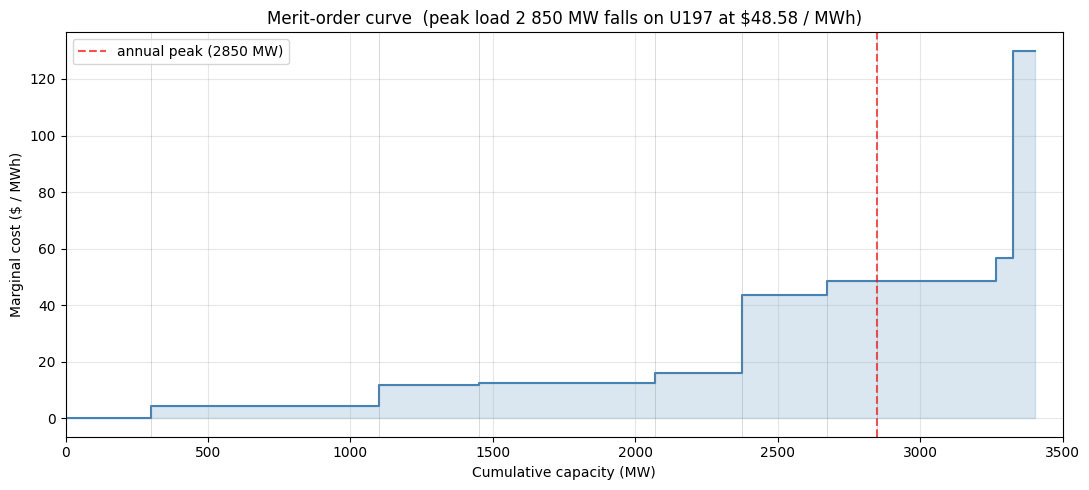

In [3]:
# Merit-order curve: cumulative capacity vs marginal cost.
merit = fleet.sort_values('usd_per_mwh').reset_index(drop=True)
merit['cum_mw'] = merit.capacity.cumsum()
fig, ax = plt.subplots(figsize=(11, 5))
x = [0]; y = [0]
for _, r in merit.iterrows():
    x.extend([r.cum_mw - r.capacity, r.cum_mw])
    y.extend([r.usd_per_mwh, r.usd_per_mwh])
ax.step(x, y, color='steelblue', linewidth=1.5, where='pre')
ax.fill_between(x, 0, y, alpha=0.2, color='steelblue', step='pre')
ax.axvline(2850, color='red', linestyle='--', alpha=0.7, label='annual peak (2850 MW)')
for label, mw in [('hydro', 300), ('+ nuclear', 1100), ('+ coal U350', 1450),
                  ('+ U155', 2070), ('+ U76', 2374), ('+ U100', 2674), ('+ U197 partial', 2850)]:
    ax.axvline(mw, color='gray', linewidth=0.5, alpha=0.4)
ax.set_xlabel('Cumulative capacity (MW)'); ax.set_ylabel('Marginal cost ($ / MWh)')
ax.set_title(f'Merit-order curve  (peak load 2 850 MW falls on U197 at $48.58 / MWh)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 3500)
plt.tight_layout(); plt.show()

## 3. Annual load profile

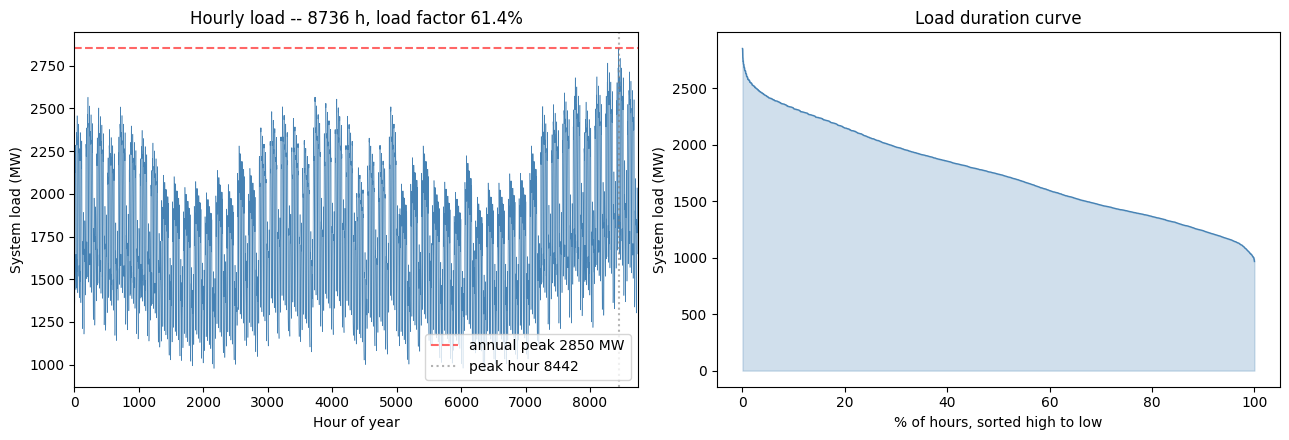

In [4]:
demand = pd.read_csv(INP / 'demand.csv')
sys_load = demand.groupby('hour')['value'].sum()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sys_load.index, sys_load.values, color='steelblue', linewidth=0.4)
axes[0].axhline(2850, color='red', linestyle='--', alpha=0.6, label='annual peak 2850 MW')
peak_h = int(sys_load.idxmax())
axes[0].axvline(peak_h, color='gray', linestyle=':', alpha=0.6, label=f'peak hour {peak_h}')
axes[0].set_xlabel('Hour of year'); axes[0].set_ylabel('System load (MW)')
axes[0].set_title(f'Hourly load -- 8736 h, load factor {sys_load.mean()/sys_load.max():.1%}')
axes[0].legend(loc='lower right'); axes[0].set_xlim(0, 8736)
sorted_load = sys_load.sort_values(ascending=False).reset_index(drop=True)
axes[1].plot(np.arange(len(sorted_load)) / len(sorted_load) * 100, sorted_load.values,
             color='steelblue', linewidth=1.0)
axes[1].fill_between(np.arange(len(sorted_load)) / len(sorted_load) * 100, 0, sorted_load.values,
                     alpha=0.25, color='steelblue')
axes[1].set_xlabel('% of hours, sorted high to low'); axes[1].set_ylabel('System load (MW)')
axes[1].set_title('Load duration curve')
plt.tight_layout(); plt.show()

## 4. Run full-year PCM

```bash
cd examples/rts79
python -m prepshot.pcm . --year 2020 --horizon 24 --step 24
```

Wall time ~22 s on commodity hardware. We run it programmatically below for the validation cells.

In [5]:
import time
sys.argv = [sys.argv[0]]
os.chdir(this_dir)
from prepshot.set_up import initialize_environment
from prepshot.pcm import (
    _build_window_params, _override_existing_fleet,
    load_fixed_capacity, _extract_window_dispatch,
)
from prepshot.model import create_model
from prepshot.solver import solve_model

full_params = initialize_environment({
    'filepath': str(this_dir),
    'config_filename': str(this_dir / 'config.json'),
    'params_filename': str(this_dir / 'params.json'),
})
full_hours = list(full_params['hour'])
cap = load_fixed_capacity(pathlib.Path('input/capacity_pcm.csv'), 2020, this_dir)
state = {'hydro_storage': {}, 'battery_storage': {}}

t0 = time.perf_counter()
window_outs = []
t = 0
while t < len(full_hours):
    wh = full_hours[t:t + 24]
    win = _build_window_params(full_params, 2020, wh, state)
    _override_existing_fleet(win, cap)
    m = create_model(win)
    assert solve_model(m, win)
    window_outs.append(_extract_window_dispatch(m, wh, 2020))
    t += 24
elapsed = time.perf_counter() - t0
gen_df = pd.concat([pd.DataFrame(w['gen']) for w in window_outs], ignore_index=True)
gen_df = gen_df.merge(registry[['tech', 'carrier']], on='tech')
print(f'Solved {len(window_outs)} windows in {elapsed:.1f} s')
print(f'Annual gen: {gen_df.value.sum() / 1000:.1f} GWh; demand: {demand.value.sum() / 1000:.1f} GWh')

2026-05-08 12:32:32 INFO: Set parameter solver to value highs


2026-05-08 12:32:32 INFO: Set parameter input folder to value input


2026-05-08 12:32:32 INFO: Set parameter output_filename to value baseline.nc


2026-05-08 12:32:32 INFO: Set parameter time_length to value 8736


2026-05-08 12:32:33 INFO: Start running 'create_model'


...

2026-05-08 12:32:56 INFO: Finished 'create_model' in 0.04 seds


2026-05-08 12:32:56 INFO: Start running 'solve_model'


2026-05-08 12:32:56 INFO: Finished 'solve_model' in 0.02 seds


Coefficient ranges:
  Matrix [1e+00, 9e+03]
  Cost   [4e-01, 5e+07]
  Bound  [3e+00, 3e+00]
  RHS    [1e+01, 1e+03]
Presolving model
1392 rows, 2952 cols, 7224 nonzeros  0s
1061 rows, 2621 cols, 7864 nonzeros  0s
766 rows, 1078 cols, 3442 nonzeros  0s
620 rows, 932 cols, 2965 nonzeros  0s
614 rows, 926 cols, 2940 nonzeros  0s
Presolve : Reductions: rows 614(-3458); columns 926(-2910); elements 2940(-9504)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -4.8408265387e+02 Pr: 592(688475) 0s
        662     1.5554737148e+08 Pr: 0(0); Du: 0(4.04725e-11) 0s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 662
Objective value     :  1.5554737148e+08
HiGHS run time      :          0.01
Running HiGHS 1.7.0 (git hash: 50670fd): Copyright (c) 2024 HiGHS under MIT licence terms
Hessian has dimension 3836 but no nonzeros, so is ignored
Coefficient ra

Solved 364 windows in 23.3 s
Annual gen: 15297.1 GWh; demand: 15297.1 GWh


## 5. Validation

In [6]:
REFERENCE = {
    'annual_gwh_total': 15297.1,
    'annual_by_carrier': {'nuclear': 6979, 'coal': 5627, 'hydro': 2621, 'oil': 70},
    'cf_envelope': {'nuclear': '> 99%', 'hydro': '> 99%',
                    'coal': '40-65%', 'oil': '< 5%'},
    'peak_hour': 8442,
    'peak_dispatch_mw': {'hydro': 300, 'nuclear': 800, 'coal': 1274, 'oil': 476},
}
NAMEPLATE_MW = {'hydro': 300, 'nuclear': 800, 'coal': 1274, 'oil': 1031}

annual = (gen_df.groupby('carrier')['value'].sum() / 1000).to_dict()
cf = {c: annual[c] * 1000 / (NAMEPLATE_MW[c] * 8736) for c in NAMEPLATE_MW}
peak_disp = (
    gen_df[gen_df['hour'] == REFERENCE['peak_hour']]
    .groupby('carrier')['value'].sum().to_dict()
)

print(f"Annual energy:  PREP-SHOT {gen_df.value.sum()/1000:>8.1f} GWh   reference ~{REFERENCE['annual_gwh_total']:.1f} GWh")
print()
print(f"{'carrier':<10}{'PREP-SHOT GWh':>14}  {'reference GWh':>14}  {'CF':>7}  reference envelope")
for c, ref_gwh in REFERENCE['annual_by_carrier'].items():
    print(f"{c:<10}{annual.get(c,0):>14.1f}  {ref_gwh:>14}  {cf[c]*100:>6.1f}%  {REFERENCE['cf_envelope'][c]}")
print()
print(f"Peak-hour ({REFERENCE['peak_hour']}) dispatch (MW):")
print(f"{'carrier':<10}{'PREP-SHOT':>11}  {'reference':>11}  {'diff':>7}")
for c, ref_mw in REFERENCE['peak_dispatch_mw'].items():
    a = peak_disp.get(c, 0)
    print(f'{c:<10}{a:>11.1f}  {ref_mw:>11}  {a-ref_mw:>+7.2f}')

Annual energy:  PREP-SHOT  15297.1 GWh   reference ~15297.1 GWh

carrier    PREP-SHOT GWh   reference GWh       CF  reference envelope
nuclear           6978.8            6979    99.9%  > 99%
coal              5627.4            5627    50.6%  40-65%
hydro             2620.8            2621   100.0%  > 99%
oil                 70.1              70     0.8%  < 5%

Peak-hour (8442) dispatch (MW):
carrier     PREP-SHOT    reference     diff
hydro           300.0          300    +0.00
nuclear         800.0          800    +0.00
coal           1274.0         1274    +0.00
oil             476.0          476    -0.00


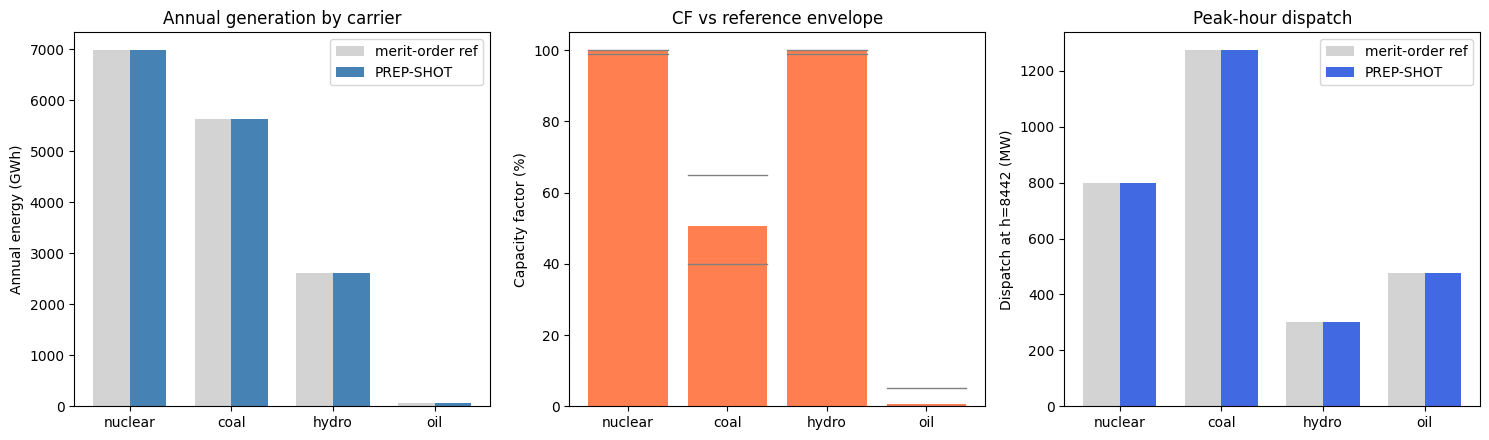

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
carriers = ['nuclear', 'coal', 'hydro', 'oil']
ref_gwh = [REFERENCE['annual_by_carrier'][c] for c in carriers]
act_gwh = [annual[c] for c in carriers]
x = np.arange(len(carriers))
axes[0].bar(x - 0.18, ref_gwh, width=0.36, label='merit-order ref', color='lightgray')
axes[0].bar(x + 0.18, act_gwh, width=0.36, label='PREP-SHOT', color='steelblue')
axes[0].set_xticks(x); axes[0].set_xticklabels(carriers)
axes[0].set_ylabel('Annual energy (GWh)'); axes[0].legend()
axes[0].set_title('Annual generation by carrier')

cf_pct = [cf[c]*100 for c in carriers]
envelope_lo = [99, 40, 99, 0]
envelope_hi = [100, 65, 100, 5]
axes[1].bar(x, cf_pct, color='coral')
for i, c in enumerate(carriers):
    axes[1].plot([x[i]-0.4, x[i]+0.4], [envelope_lo[i], envelope_lo[i]], color='gray', linewidth=1)
    axes[1].plot([x[i]-0.4, x[i]+0.4], [envelope_hi[i], envelope_hi[i]], color='gray', linewidth=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(carriers)
axes[1].set_ylabel('Capacity factor (%)'); axes[1].set_title('CF vs reference envelope')
axes[1].set_ylim(0, 105)

# Peak-hour stack
ref_peak = [REFERENCE['peak_dispatch_mw'][c] for c in carriers]
act_peak = [peak_disp.get(c, 0) for c in carriers]
axes[2].bar(x - 0.18, ref_peak, width=0.36, label='merit-order ref', color='lightgray')
axes[2].bar(x + 0.18, act_peak, width=0.36, label='PREP-SHOT', color='royalblue')
axes[2].set_xticks(x); axes[2].set_xticklabels(carriers)
axes[2].set_ylabel(f"Dispatch at h={REFERENCE['peak_hour']} (MW)")
axes[2].legend(); axes[2].set_title('Peak-hour dispatch')
plt.tight_layout(); plt.show()

## 6. Notes

* **Why the merit-order benchmark works.** RTS-79's plant costs span more than two orders of magnitude ($0 hydro to $130 oil peakers). At any load level the cheapest unused units fill in first. The few transmission constraints that can bind (line 7-8 outbound from the U100 cluster) don't change the carrier-level dispatch -- they only affect within-carrier unit selection.
* **Peak-hour LMP.** Most buses see $48.58/MWh (= U197 marginal cost). bus 7 is the exception -- LMP comes out to $43.66/MWh because line 7-8 binds outward from bus 7's U100 surplus, making the LP dual non-unique (gen upper bound and line bind together). The total cost is correct.
* **U50 hydro is fixed-cost dispatchable.** We model the 6 hydro units as standard `cost_var` techs at $0.001/MWh, not as cascading reservoirs. RTS-79's hydro budget is small (300 MW total) and the texts treat it as flat baseload, so this matches the reference behavior.

## See also

* PJM 5-bus ([`PJM5.ipynb`](../pjm5/PJM5.ipynb)) -- minimal LMP / DC OPF check.
* RTS-96 ([`RTS96.ipynb`](../rts96/RTS96.ipynb)) -- 3-area extension on the same 24-bus topology.